<a href="https://www.kaggle.com/code/pratishchaudhary/smartphone-addiction?scriptVersionId=340140403" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp"/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/test.csv")
submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv")

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
train.sample(5)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
323427,323427,30.0,9.36,2.71,1.68,1.80,4.81,118.0,175.0,12.22,Female,High,Yes,1
513003,513003,33.0,9.22,3.13,0.79,NaN,4.95,114.0,130.0,11.33,Other,High,Yes,1
377726,377726,19.0,10.87,2.99,3.08,NaN,6.25,195.0,128.0,8.89,Other,Low,No,1
202144,202144,23.0,6.44,1.81,0.22,1.58,8.60,243.0,123.0,10.50,Other,High,Yes,1
561752,561752,32.0,12.04,3.91,3.90,3.21,5.66,211.0,22.0,13.74,Female,High,No,1


In [4]:
train.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


<Axes: xlabel='addicted_label', ylabel='count'>

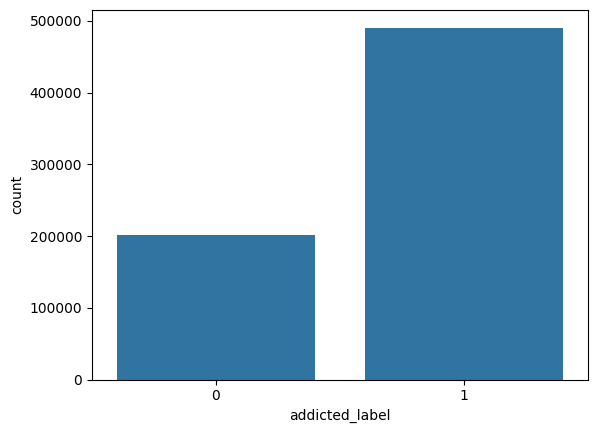

In [5]:
sns.countplot(x=train['addicted_label'])

outliers in social_media_hours


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(train.drop('addicted_label',axis=1),train['addicted_label'],stratify=train['addicted_label'],test_size=0.2)

In [7]:
#imputation
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
imputer = ColumnTransformer(transformers=[
    ('imp1',SimpleImputer(strategy="mean"),[1, 2, 3,4, 5, 6,7, 8, 9]),
    ('imp2',SimpleImputer(strategy="most_frequent"),[10,11,12])
],
    remainder='passthrough'
)

In [8]:
columns= [ 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day',
       'weekend_screen_time', 'gender', 'stress_level',
       'academic_work_impact','id']
cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day',
       'weekend_screen_time']

In [9]:
X_train = pd.DataFrame(imputer.fit_transform(X_train),columns=columns)

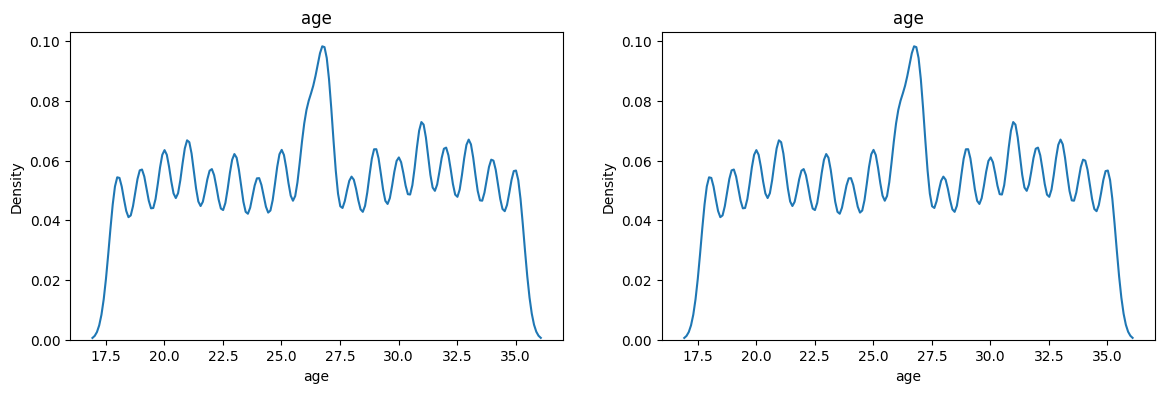

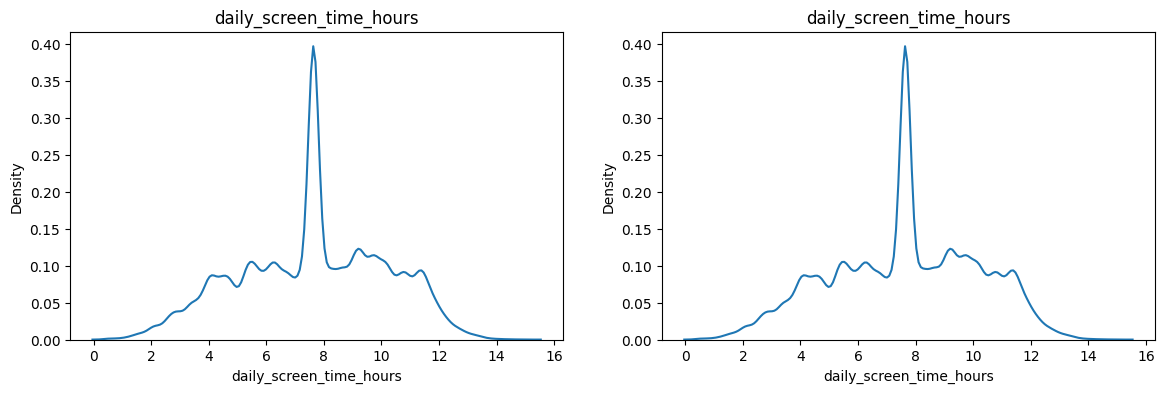

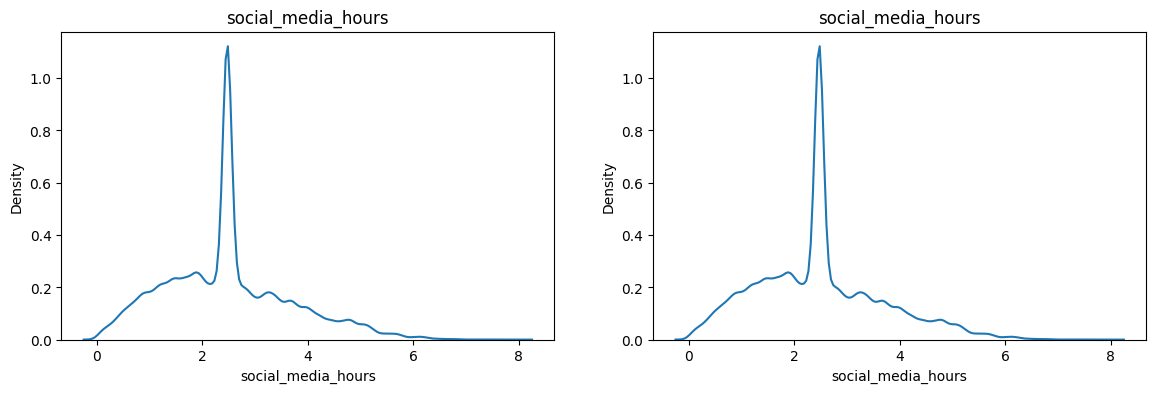

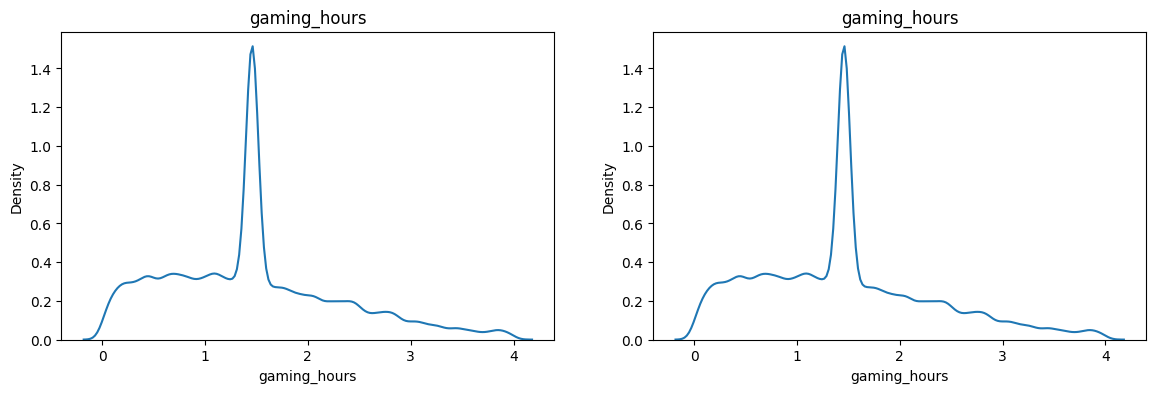

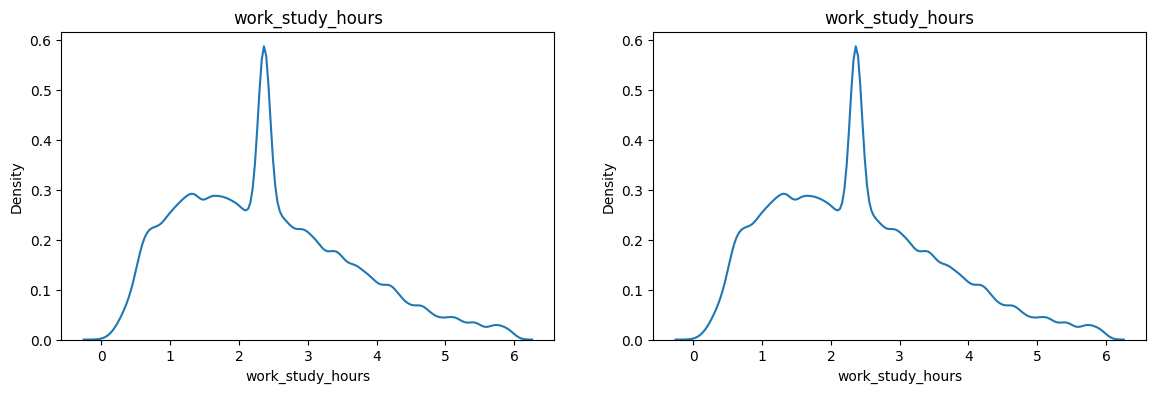

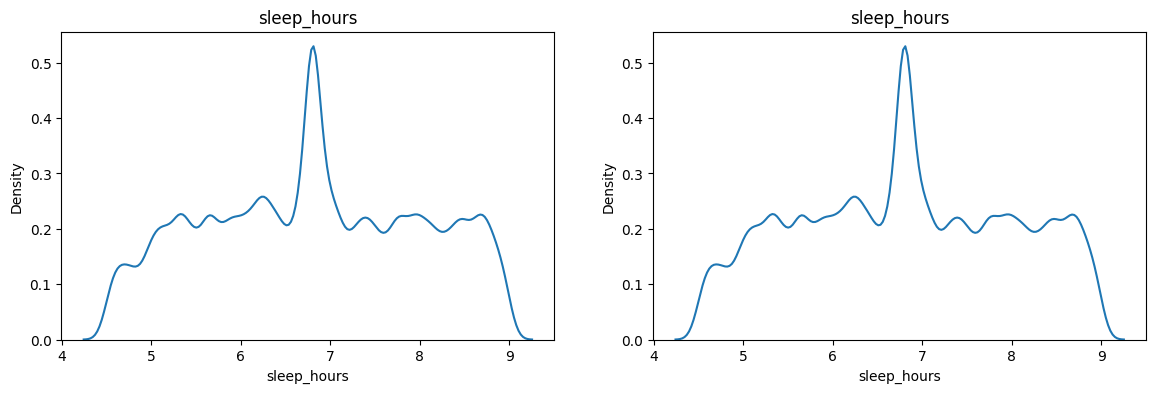

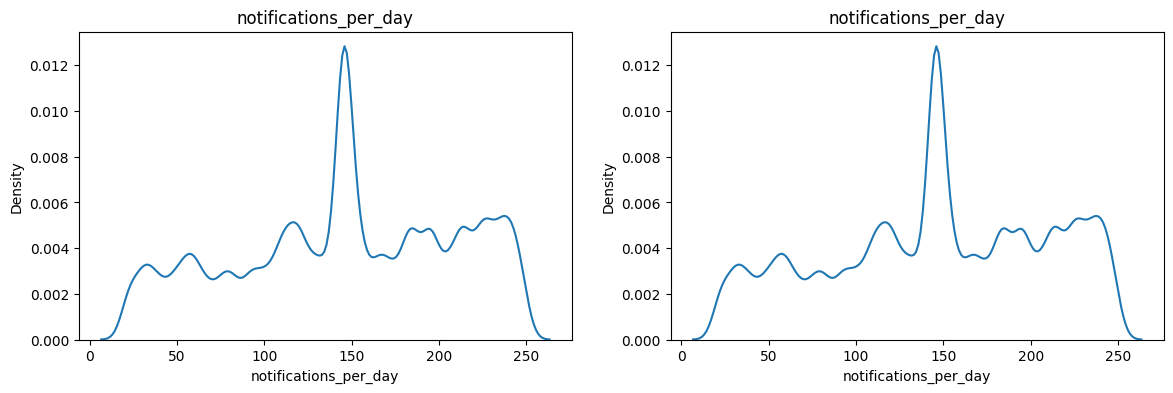

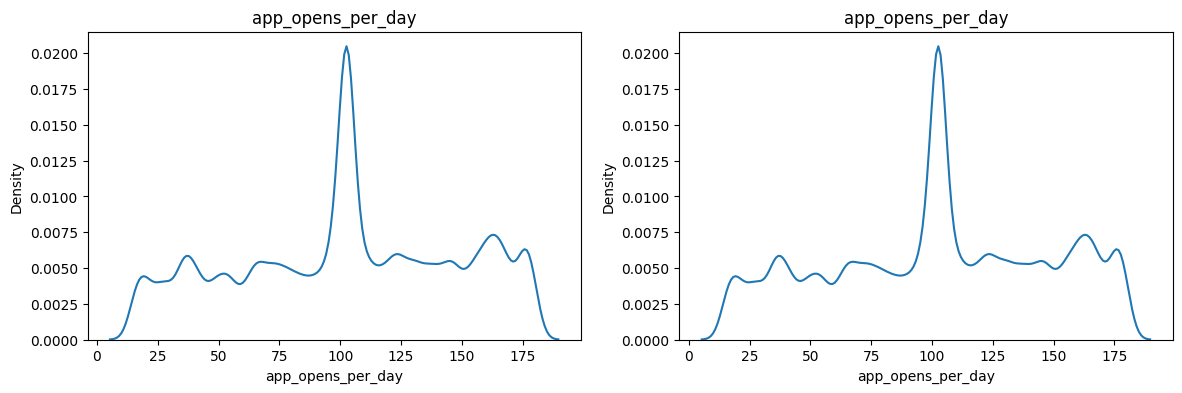

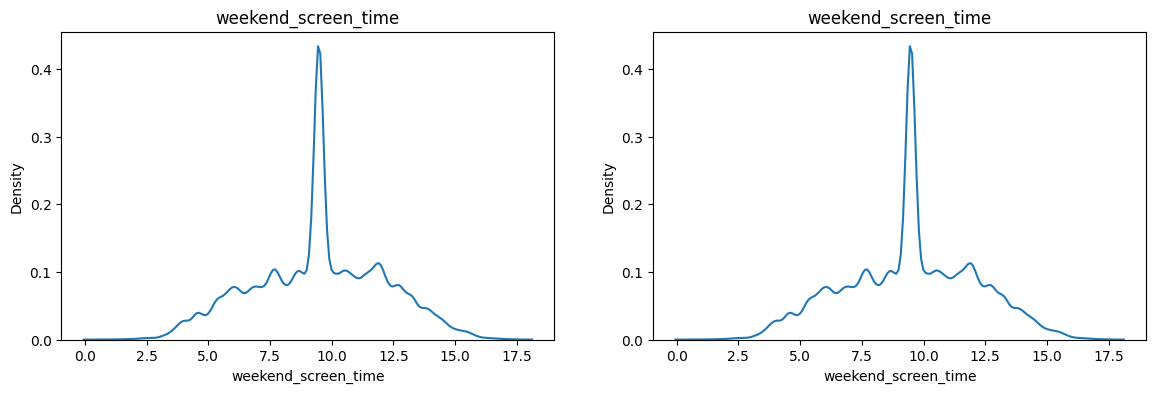

In [10]:
X_train[cols] = X_train[cols].astype(np.float64)
for col in cols:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.show()

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

encoder = ColumnTransformer(transformers=[
    ('enc1',OrdinalEncoder(categories=[['Low','Medium','High']]),[10]),
    ('enc2',OrdinalEncoder(categories=[['No','Yes']]),[11]),
    ('enc3',OneHotEncoder(sparse_output=True,drop='first'),[9])
],
remainder='passthrough'
)

In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)

In [13]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('imputer',imputer),
    ('encoder',encoder),
    ('model',model)
])

In [14]:
from sklearn import set_config
set_config(display='diagram')

In [15]:
params = {
    'model__max_depth':[1,2,3,4,5,None]
}